<a href="https://colab.research.google.com/github/Thulasi604/Hospital-Readmission-Prediction-Healthcare-Analytics-Project/blob/main/Hospital_Readmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("diabetic_data.zip")

# Take a quick look
print(df.shape)  # See how many rows and columns
print(df.head()) # See the first 5 rows

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [3]:
df['readmitted']

,readmitted
0,NO
1,>30
2,NO
3,NO
4,NO
...,...
101761,>30
101762,NO
101763,NO
101764,NO


In [2]:
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [4]:
# Replace '?' with NaN so Python recognizes them as missing
df = df.replace('?', np.nan)

In [5]:
# Create binary target
df['high_risk'] = np.where(df['readmitted'] == '<30', 1, 0)

# Filter out the '>30' group (we only want <30 vs NO)
df = df[df['readmitted'] != '>30']

# Check your new target
df['high_risk'].value_counts()

,count
high_risk,
0,54864
1,11357


In [6]:
df['readmitted']

,readmitted
0,NO
2,NO
3,NO
4,NO
6,NO
...,...
101759,NO
101762,NO
101763,NO
101764,NO


In [7]:
df['high_risk']


,high_risk
0,0
2,0
3,0
4,0
6,0
...,...
101759,0
101762,0
101763,0
101764,0


In [8]:
# STEP 1: First, replace all the '?' with actual NaN (so Python knows they are missing)
df = df.replace('?', np.nan)

# STEP 2: Look at which columns have missing data
print(df.isnull().sum())

# STEP 3: Fill in missing NUMBERS with the MEDIAN (middle value)
# We do this because the 'average' can be thrown off by extreme outliers.
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

for col in num_cols:
    median_value = df[col].median()  # Calculate the middle value
    df[col].fillna(median_value, inplace=True)  # Fill the blanks with that middle value

# STEP 4: Fill in missing TEXT with the MODE (most common word)
# We do this because it's the safest guess for categories like "Medical Specialty".
text_cols = ['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']

for col in text_cols:
    mode_value = df[col].mode()[0]  # Find the most common word in that column
    df[col].fillna(mode_value, inplace=True)  # Fill the blanks with that word

# STEP 5: Double-check that all blanks are filled
print(df.isnull().sum())  # This should show '0' for all columns now!

encounter_id                    0
patient_nbr                     0
race                         1735
gender                          0
age                             0
weight                      64534
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  26428
medical_specialty           31733
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         17
diag_2                        284
diag_3                       1085
number_diagnoses                0
max_glu_serum               62811
A1Cresult                   55003
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

/tmp/ipykernel_649/175748001.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)  # Fill the blanks with that middle value
/tmp/ipykernel_649/175748001.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                      64534
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  26428
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               62811
A1Cresult                   55003
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
# STEP 1: Create your target variable (High Risk = Readmitted within 30 days)
df['high_risk'] = np.where(df['readmitted'] == '<30', 1, 0)

# STEP 2: Filter out the '>30' group (we only want <30 vs NO)
df_clean = df[df['readmitted'] != '>30'].copy()

# STEP 3: See how many patients are in each group
print("=" * 50)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 50)
print(df_clean['high_risk'].value_counts())
print("\n")
print(f"Total patients in analysis: {len(df_clean):,}")
print(f"High Risk (<30 days): {df_clean['high_risk'].sum():,} patients")
print(f"Low Risk (No readmission): {(len(df_clean) - df_clean['high_risk'].sum()):,} patients")

# STEP 4: Calculate the readmission rate
readmission_rate = (df_clean['high_risk'].sum() / len(df_clean)) * 100
print(f"\n📊 30-Day Readmission Rate: {readmission_rate:.2f}%")

TARGET VARIABLE DISTRIBUTION
high_risk
0    54864
1    11357
Name: count, dtype: int64


Total patients in analysis: 66,221
High Risk (<30 days): 11,357 patients
Low Risk (No readmission): 54,864 patients

📊 30-Day Readmission Rate: 17.15%


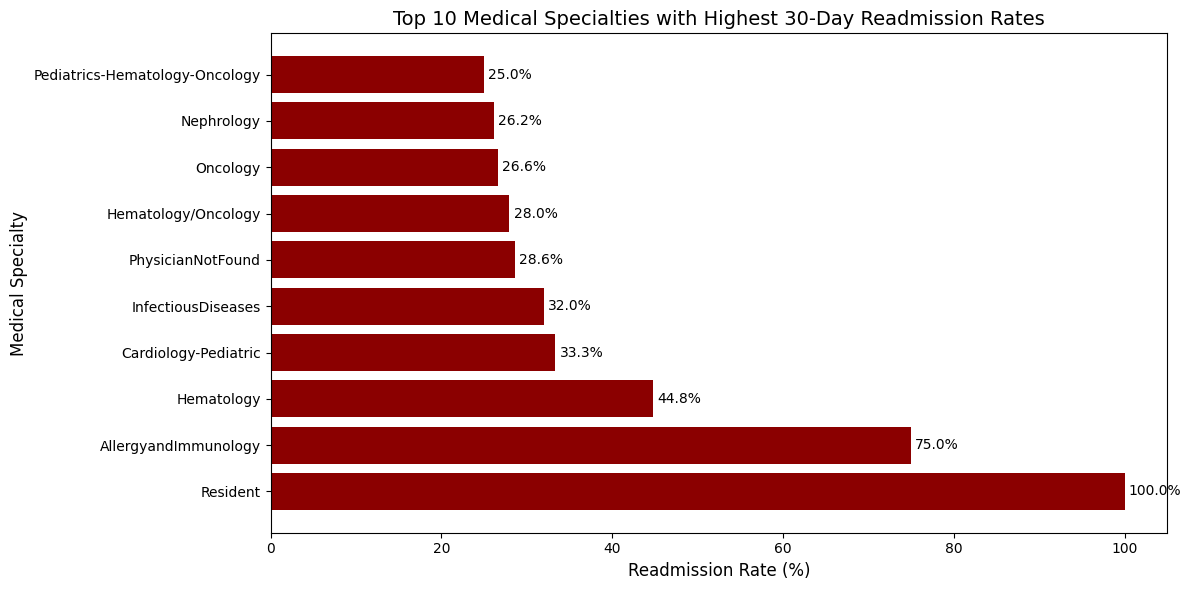


📊 Top 5 Highest Risk Specialties:
Resident: 100.00% readmission rate
AllergyandImmunology: 75.00% readmission rate
Hematology: 44.83% readmission rate
Cardiology-Pediatric: 33.33% readmission rate
InfectiousDiseases: 32.00% readmission rate


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Group by medical specialty and calculate readmission rate
specialty_risk = df_clean.groupby('medical_specialty')['high_risk'].mean().sort_values(ascending=False) * 100
specialty_risk = specialty_risk.head(10)  # Top 10 highest risk specialties

# STEP 2: Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.barh(specialty_risk.index, specialty_risk.values, color='darkred')

# STEP 3: Add labels and title
plt.xlabel('Readmission Rate (%)', fontsize=12)
plt.ylabel('Medical Specialty', fontsize=12)
plt.title('Top 10 Medical Specialties with Highest 30-Day Readmission Rates', fontsize=14)
plt.xlim(0, max(specialty_risk.values) + 5)

# Add percentage labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

# STEP 4: Print the results as a table
print("\n📊 Top 5 Highest Risk Specialties:")
print("=" * 50)
for specialty, rate in specialty_risk.head(5).items():
    print(f"{specialty}: {rate:.2f}% readmission rate")

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# STEP 1: Select categorical columns to encode
categorical_cols = ['gender', 'age', 'medical_specialty', 'admission_type_id',
                    'discharge_disposition_id', 'admission_source_id']

# STEP 2: ENCODE FIRST - Create dummy variables
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Original columns: {len(df_clean.columns)}")
print(f"Columns after encoding: {len(df_encoded.columns)}")

# STEP 3: Prepare features and target
numerical_features = ['time_in_hospital', 'num_medications', 'num_lab_procedures',
                      'number_emergency', 'num_procedures', 'number_diagnoses']

# Get all encoded column names
encoded_features = [col for col in df_encoded.columns if col.startswith(tuple(categorical_cols))]

# Combine numerical + encoded features
all_features = numerical_features + encoded_features

X = df_encoded[all_features]
y = df_encoded['high_risk']

# STEP 4: SPLIT SECOND - Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 5: SCALE THIRD - Scale ONLY after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 6: Apply SMOTE (on training data only)
smote = SMOTE(random_state=42, sampling_strategy=0.7)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nTraining set size: {X_train_resampled.shape[0]:,} rows")
print(f"High Risk samples: {sum(y_train_resampled == 1):,}")
print(f"Low Risk samples: {sum(y_train_resampled == 0):,}")

# STEP 7: Train the model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

# STEP 8: Evaluate
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE (Correct Order)")
print("=" * 60)
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print(f"High Risk Recall: {classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk'])}")

# STEP 9: Feature Importance (Top 10)
coefficients = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': model.coef_[0]
})
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Odds_Ratio', ascending=False)

print("\n" + "=" * 60)
print("TOP 10 FEATURES BY ODDS RATIO")
print("=" * 60)
print(coefficients.head(10))

Original columns: 51
Columns after encoding: 170

Training set size: 74,699 rows
High Risk samples: 30,758
Low Risk samples: 43,941

FINAL MODEL PERFORMANCE (Correct Order)
AUC Score: 0.664
High Risk Recall:               precision    recall  f1-score   support

    Low Risk       0.88      0.60      0.72     10923
   High Risk       0.25      0.62      0.36      2322

    accuracy                           0.61     13245
   macro avg       0.57      0.61      0.54     13245
weighted avg       0.77      0.61      0.66     13245


TOP 10 FEATURES BY ODDS RATIO
                          Feature  Coefficient  Odds_Ratio
3                number_emergency     0.302986    1.353895
5                number_diagnoses     0.236527    1.266841
109   discharge_disposition_id_22     0.191549    1.211124
1                 num_medications     0.152264    1.164468
91     discharge_disposition_id_3     0.131683    1.140746
87            admission_type_id_6     0.123998    1.132013
93     discharge_disp

In [16]:
import pandas as pd

# Save your final dataset with predictions
# Create a Series with predictions and the original index from X_test
predictions_series = pd.Series(model.predict_proba(X_test_scaled)[:, 1], index=X_test.index)

# Assign these predictions back to the df_clean DataFrame using the aligned index
df_clean.loc[X_test.index, 'predicted_risk'] = predictions_series

# Save to CSV for Power BI
df_clean.to_csv('diabetes_readmission_predictions.csv', index=False)
print("✅ CSV file saved! Now open Power BI.")

✅ CSV file saved! Now open Power BI.
